In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

from urllib.request import urlretrieve

In [2]:
urlretrieve(medical_charges_url, 'ml_linear_regression_medical.csv')

('ml_linear_regression_medical.csv', <http.client.HTTPMessage at 0x108ee6350>)

In [3]:
pip install pandas

  Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl (9.9 MB)
Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]━━━━ 1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

df_medical = pd.read_csv("ml_linear_regression_medical.csv")
df_medical.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
df_medical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
df_medical.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
## Inferences from the data - 
### 1. Insurance is provided from the age 18-64
### 2. 75 percent of people have BMI < 34.7, with average being 30.6. The rest are serious outliers on both ends of the spectrum
### 3. Mean number of children is 1.09, and 75% of people have less than 2 kids. 25% of people don't have kids. Number of single child applications are dominating the data, with 25% of data being between 2 and 5
### 4. Huge skewness in charges (Min - 1100 and max - 64k)

Exploratory Data Analysis

In [ ]:
# # pip install matplotlib plotly seaborn --quiet

# pip install nbformat ipython --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [7]:
# EDA for Age

df_medical['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [ ]:
fig = px.histogram(df_medical, x='age', marginal='box', nbins=47, title='Age Dist')
fig.update_layout(bargap=0.1)
fig.show()

# Interpretation of chart - 
# 1. Almost uniform distribution, with 20-30 customers at every range
# 2. If correlated with overall distribution of age in US (tot population), there are not many variations, which supports our sampling (This insurance company is representative of the overall population of the United States)
# 3. Ages 18-19 are outliers, with slight upward trend between ages 40 and 50
# 
# Why the increase for ages 18 and 19? Probably because lower premiums if you sign up before 20 

In [9]:
# EDA for BMI

df_medical['bmi'].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [ ]:
fig = px.histogram(df_medical, x='bmi', marginal='box', color_discrete_sequence=['blue'], title='BMI Dist')
fig.update_layout(bargap=0.1)
fig.show()

# Interpretation - 
## 1. Gaussian distribution

In [11]:
# EDA - Charges

df_medical['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [ ]:
fig = px.histogram(df_medical, x='charges', marginal='box', color='smoker', color_discrete_sequence=['green','grey'], title='Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

# Interpretation
# 1. Trend - Smokers pay more premiums
# 2. Most people fall under 2k - 15k
# 3. This distribution is called Power Law - Most are concentrated at the start but exponentially drop off
# 4. Non smokers - Exponentially trail off but for smokers - there are 2 hills, meaning there is another factor at play here - maybe ailments combined with smoking or light/heavy smokers?
# 5. Median charges for non smokers - 7.3k but for smokers - 35k??? 

In [13]:
# EDA for smokers

df_medical['smoker'].describe()

count     1338
unique       2
top         no
freq      1064
Name: smoker, dtype: object

In [14]:
px.histogram(df_medical, x='smoker', color='sex', title='Smoker')

In [ ]:
# Age and Charges

px.scatter(df_medical, x='age', y='charges', opacity=0.8, color='smoker',title='Age vs Charges')

# Observations - 

# 1. Medical charges increase with age, but that's not the only factor; roughly a linear trend
# 2. Three clear clusers - Major one is healthy non-smokers; 2nd is a mix of smokers and non smokers - distinct but overlapping; last cluster is exclusively smokers

In [ ]:
# BMI and Charges

px.scatter(df_medical, x='bmi', y='charges', opacity=0.8, color='smoker',title='BMI vs Charges')

# Observations - 

# 1. No clear trend for non-smokers
# 2. 2 clear clusters for smokers

In [41]:
# Children and Charges

px.violin(df_medical, x='children', y='charges', title='Children vs Charges')

# Observations - 

# 1. No clear trend for non-smokers
# 2. 2 clear clusters for smokers

Correlation

In [46]:
print(df_medical['charges'].corr(df_medical['children']))
print(df_medical['charges'].corr(df_medical['age']))
print(df_medical['charges'].corr(df_medical['bmi']))

0.0679982268479048
0.29900819333064754
0.19834096883362884


In [ ]:
# For categorical columns

smoker_values = {'no':0, 'yes':1}
smoker_numeric = df_medical['smoker'].map(smoker_values)
df_medical['charges'].corr(smoker_numeric)

## Correlation

# Denotes strength of relationship between 2 variables
# -1/1 => Perfectly linear relationship, where a change in one variable is accompanied by a perfect consistent change in the other; this is not realistic in real life
# 0 => No linear relationship, as one value increases, there's no tendency for the other value to increase / decrease
# [-1,0] and [0, 1] => There is a relationship, but not all points fall on the line

# Positive coefficient - When one value increases, the other increases too
# Negative coefficient - When one value decreases, the other decreases as well



np.float64(0.7872514304984772)

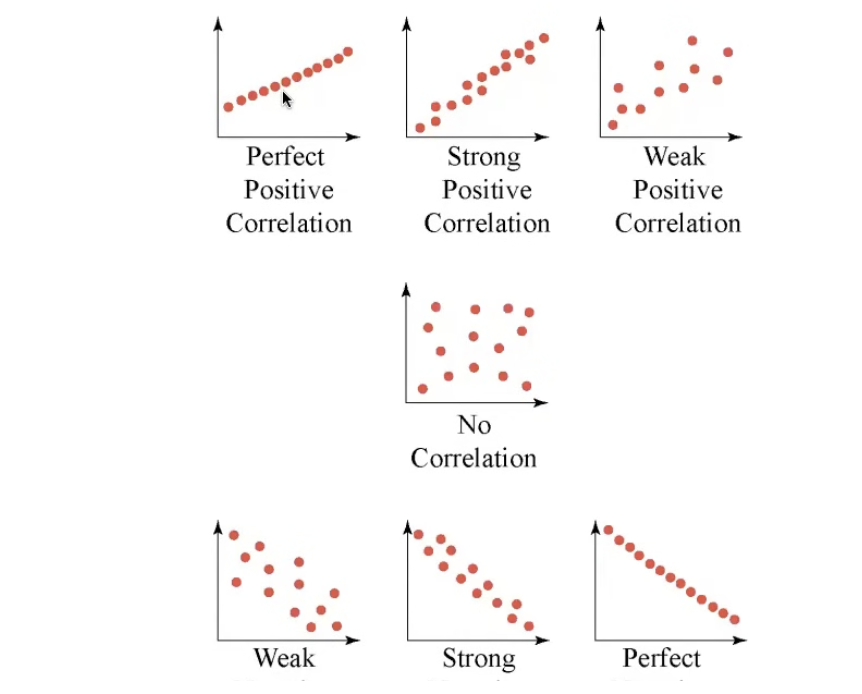

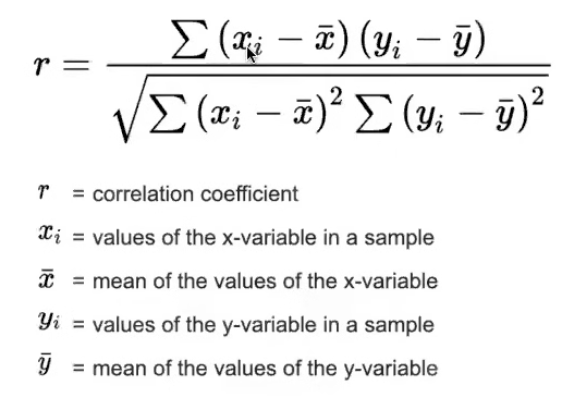

In [49]:
df_medical[["age","bmi","children","charges"]].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [ ]:
## Correlation vs Causation